# Tissue simulation, in depth — 3: the LBM engine, a different numerical route

The last two notebooks ran the same strip of tissue on **monodomain** (≈ 58 cm/s) and **bidomain**
(≈ 60 cm/s). This one runs it on the third engine, **LBM** — the lattice-Boltzmann method — which
arrives at the same wave by completely different machinery. It comes out a little *faster* on the
clock, and understanding why that is fine — not a bug — is the real lesson of this notebook and a rule
you will lean on constantly in Chapter 5.

You do not need to have run 3.1 or 3.2 first — this notebook rebuilds the tissue in one cell.

**What you'll learn**

1. **A different route to the same physics** — what LBM does instead of solving the equation directly
2. **Running it** — the same ingredients, a smaller time step
3. **The same wave** — the activation map looks just like monodomain's
4. **A different number** — LBM's CV, and the like-to-like rule that makes engine numbers usable

**Runtime**: only a few seconds of computing (LBM with a short run). On Colab, add about a minute the
first time for the install.

---
## 0. Install and import

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core — this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/RealJokerInc/cardiac-core.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. Rebuild the strip

The same 1.0 cm × 0.3 cm strip, conductivity, and left-edge electrode as the previous two notebooks:

In [3]:
g    = cc.Grid(101, 31, 0.01)                                          # 1.0 cm x 0.3 cm strip
cond = cc.ConductivityConfig.bidomain(1.74, 6.25)                     # healthy human ventricle
stim = cc.Stim.boundary(g, "left", amplitude=-52.0, start_time=1.0, duration=2.0)  # left-edge electrode

print("strip rebuilt")

strip rebuilt


---
## 2. A different route to the same physics

Monodomain and bidomain solve the propagation equation **directly**: at each step they compute how
voltage diffuses from every node to its neighbours by evaluating the diffusion term of the equation.

**LBM** — the lattice-Boltzmann method — never writes that equation down. Instead it imagines little
packets of "stuff" sitting at each node, and at every step they **stream** to neighbouring nodes and
**collide** (mix and relax) when they arrive. Do that with the right bookkeeping and diffusion
*emerges* from the streaming and collision automatically — the same physics, reached from underneath by
a different set of rules. LBM comes from computational fluid dynamics, where this trick is prized for
running fast on parallel hardware.

The one practical difference you will feel: LBM needs a **smaller time step** to stay accurate — here
`dt=0.01` ms, versus `0.05` for monodomain. So we keep the run short.

---
## 3. Run it

Same four ingredients, the `cc.lbm` factory, and the smaller `dt`:

In [4]:
sim = cc.lbm(g, "ttp06", cond, stim, dt=0.01)   # LBM engine; note the smaller time step
r = sim.run(t_end=20.0, save_every=0.5)          # shorter run — dt=0.01 means more steps per ms

print("done — LBM run complete")

done — LBM run complete


---
## 4. The same wave

Draw the activation map, exactly as in 3.1 — each node coloured by when the wave reached it:

ImageInfo(unsaved, 1060x412, panels=1, range=(2.5, 17.6), 24,356 bytes)
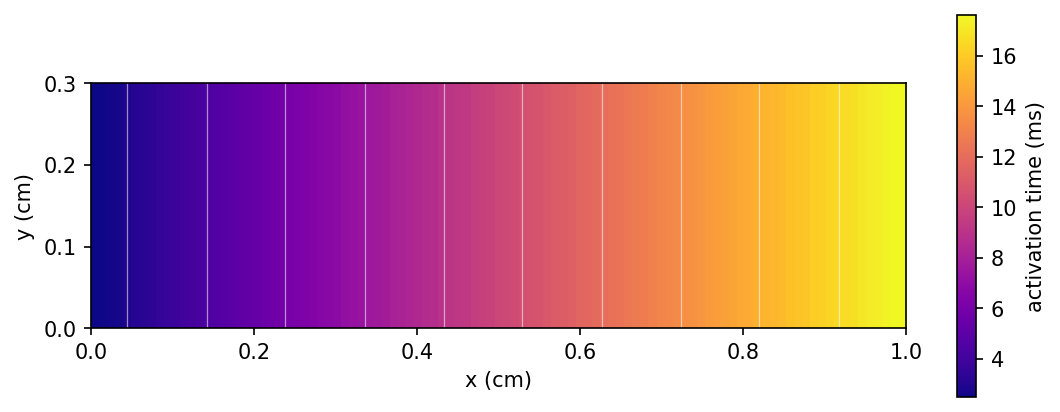

In [5]:
r.image(what="activation")   # colour each node by the time the wave arrived

Straight, evenly-spaced isochrones — the same flat, steady wavefront monodomain produced. By eye,
the propagation is indistinguishable: a clean planar wave marching left to right. LBM and the other two
engines agree on the *shape* of the wave and on everything qualitative about it. Where they differ is a
single number.

---
## 5. A different number — and the like-to-like rule

Measure the conduction velocity with the identical call used in 3.1 and 3.2:

In [6]:
cv = r.cv(x1=20, x2=80, y=15)
print(f"LBM conduction velocity = {cv:.1f} cm/s")

LBM conduction velocity = 64.3 cm/s


About **64 cm/s** — noticeably higher than monodomain's 58 and bidomain's 60 on the *identical*
tissue with the *identical* conductivity. Here that is roughly a 10% gap.

**This is not an error, and neither engine is "wrong."** The three engines discretise space and time
differently, and each discretisation carries its own small, systematic offset in the effective
diffusivity — so each reports the wave's speed on its own slightly-shifted ruler. LBM's ruler runs a
little fast relative to the finite-difference engines. (For the same reason, the O'Hara–Rudy model
`"ord"` is available only through LBM in `cardiac_core` — the engines are genuinely different machines,
not skins over one solver.)

The consequence is a rule worth taping to your monitor:

> **Compare like-to-like.** When you change something — halve the conductivity, add a drug, carve a
> scar — and want to know how the wave responds, run the *same engine* before and after and compare
> those two numbers. Never compare one engine's absolute CV against another's; the ruler changes out
> from under you. An engine is perfectly trustworthy against **itself**.

Chapter 5 turns exactly these knobs and measures their effect, and it obeys this rule throughout: every
comparison is an engine against itself.

### Try it yourself

See the rule in action. Halve the conductivity — change `cc.ConductivityConfig.bidomain(1.74, 6.25)`
to `cc.ConductivityConfig.bidomain(0.87, 3.125)` in the rebuild cell — and re-run down to the CV. The
LBM speed drops (weaker coupling → slower wave). That *drop*, LBM-vs-LBM, is a real and trustworthy
result; the raw 64-vs-58 gap against monodomain is not something to read anything into.

---
## Recap

- **LBM** reaches the same propagation physics by a different numerical route — streaming and colliding
  packets on a lattice rather than solving the diffusion equation directly — and needs a **smaller time
  step** (`dt=0.01`).
- On the identical strip it produces the **same flat wave** but a **higher CV** (≈ 64 cm/s vs
  monodomain's ≈ 58) — a systematic numerical offset, **not** an error.
- The takeaway rule: **compare like-to-like** — an engine against itself across conditions, never one
  engine's absolute number against another's.

**Where next**: that completes the tour of building tissue and the three engines. Chapter 4 puts the
tissue to work with **pacing** — driving it beat after beat to measure how it recovers between beats and
how fast you can push it before it starts to fail.